# Phase 1: Data Understanding

**Business Problem:** Predict probability of loan default (90+ days late) 
to help a lender make approval decisions.

**Dataset:** Give Me Some Credit — Kaggle (150,000 borrowers, 11 features)

**Key Findings:**
- Severe class imbalance: 93.3% non-default, 6.7% default
- Missing values: MonthlyIncome (20%), NumberOfDependents (2.6%)
- Notable outliers in RevolvingUtilization, DebtRatio, age
- Target variable: SeriousDlqin2yrs (binary)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries loaded ✓")

Libraries loaded ✓


In [5]:
df = pd.read_csv('cs-training.csv', index_col=0)

print(f"Shape: {df.shape}\n")
print(f"Columns : {df.columns}\n")
print(f"First 5 Rows: \n {df.head()}")

Shape: (150000, 11)

Columns : Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

First 5 Rows: 
    SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
1                 1                                 0.766   45   
2                 0                                 0.957   40   
3                 0                                 0.658   38   
4                 0                                 0.234   30   
5                 0                                 0.907   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
1                                     2      0.803       9120.000   
2                                     0      0.122       2600.000 

#### Column Guide

In [3]:
column_guide = {
    'SeriousDlqin2yrs': 'TARGET — 1 if borrower was 90+ days late on any payment in 2 years',
    'RevolvingUtilizationOfUnsecuredLines': 'Credit card usage ratio (balance / limit). >1 means over limit',
    'age': 'Borrower age in years',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Times 30-59 days late in last 2 years',
    'DebtRatio': 'Monthly debt payments / monthly gross income',
    'MonthlyIncome': 'Self-reported monthly income in USD',
    'NumberOfOpenCreditLinesAndLoans': 'Total open loans + lines of credit',
    'NumberOfTimes90DaysLate': 'Times 90+ days late (severe delinquency)',
    'NumberRealEstateLoansOrLines': 'Mortgage and real estate loans count',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Times 60-89 days late in last 2 years',
    'NumberOfDependents': 'Number of dependents (family members relying on borrower)'
}

for col, desc in column_guide.items():
    print(f"{col}\n  → {desc}\n")

SeriousDlqin2yrs
  → TARGET — 1 if borrower was 90+ days late on any payment in 2 years

RevolvingUtilizationOfUnsecuredLines
  → Credit card usage ratio (balance / limit). >1 means over limit

age
  → Borrower age in years

NumberOfTime30-59DaysPastDueNotWorse
  → Times 30-59 days late in last 2 years

DebtRatio
  → Monthly debt payments / monthly gross income

MonthlyIncome
  → Self-reported monthly income in USD

NumberOfOpenCreditLinesAndLoans
  → Total open loans + lines of credit

NumberOfTimes90DaysLate
  → Times 90+ days late (severe delinquency)

NumberRealEstateLoansOrLines
  → Mortgage and real estate loans count

NumberOfTime60-89DaysPastDueNotWorse
  → Times 60-89 days late in last 2 years

NumberOfDependents
  → Number of dependents (family members relying on borrower)



#### Target Variable Imbalance Check

Target Distribution:
                   Count  Percentage
SeriousDlqin2yrs                    
0                 139974      93.320
1                  10026       6.680


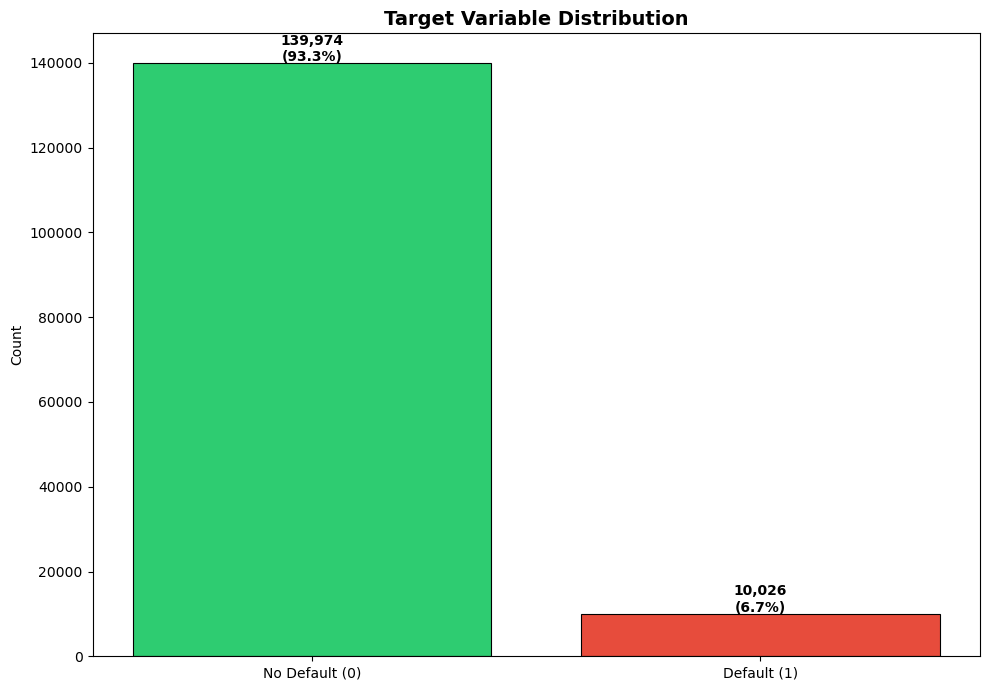

In [14]:
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print("Target Distribution:")
print(pd.DataFrame({'Count': target_counts, 'Percentage': target_pct.round(2)}))

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.bar(['No Default (0)', 'Default (1)'], target_counts.values, 
       color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 500, f'{v:,}\n({target_pct.values[i]:.1f}%)', 
            ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150)
plt.show()

#### Missing Values

In [18]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print("Missing Value Report:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Value Report:
                    Missing Count  Missing %
MonthlyIncome               29731     19.820
NumberOfDependents           3924      2.620


#### Basic Statistics

In [19]:
print("Descriptive Statistics:")
df.describe().T

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.000,0.067,0.250,0.000,0.000,0.000,0.000,1.000
RevolvingUtilizationOfUnsecuredLines,150000.000,6.048,249.755,0.000,0.030,0.154,0.559,50708.000
age,150000.000,52.295,14.772,0.000,41.000,52.000,63.000,109.000
NumberOfTime30-59DaysPastDueNotWorse,150000.000,0.421,4.193,0.000,0.000,0.000,0.000,98.000
DebtRatio,150000.000,353.005,2037.819,0.000,0.175,0.367,0.868,329664.000
MonthlyIncome,120269.000,6670.221,14384.674,0.000,3400.000,5400.000,8249.000,3008750.000
NumberOfOpenCreditLinesAndLoans,150000.000,8.453,5.146,0.000,5.000,8.000,11.000,58.000
NumberOfTimes90DaysLate,150000.000,0.266,4.169,0.000,0.000,0.000,0.000,98.000
NumberRealEstateLoansOrLines,150000.000,1.018,1.130,0.000,0.000,1.000,2.000,54.000
NumberOfTime60-89DaysPastDueNotWorse,150000.000,0.240,4.155,0.000,0.000,0.000,0.000,98.000


# 2. Exploratory Data Analysis

Goal: Understand the distribution of each feature, spot outliers, and identify
which variables look most predictive of default before we touch any models.

#### Feature Distributions

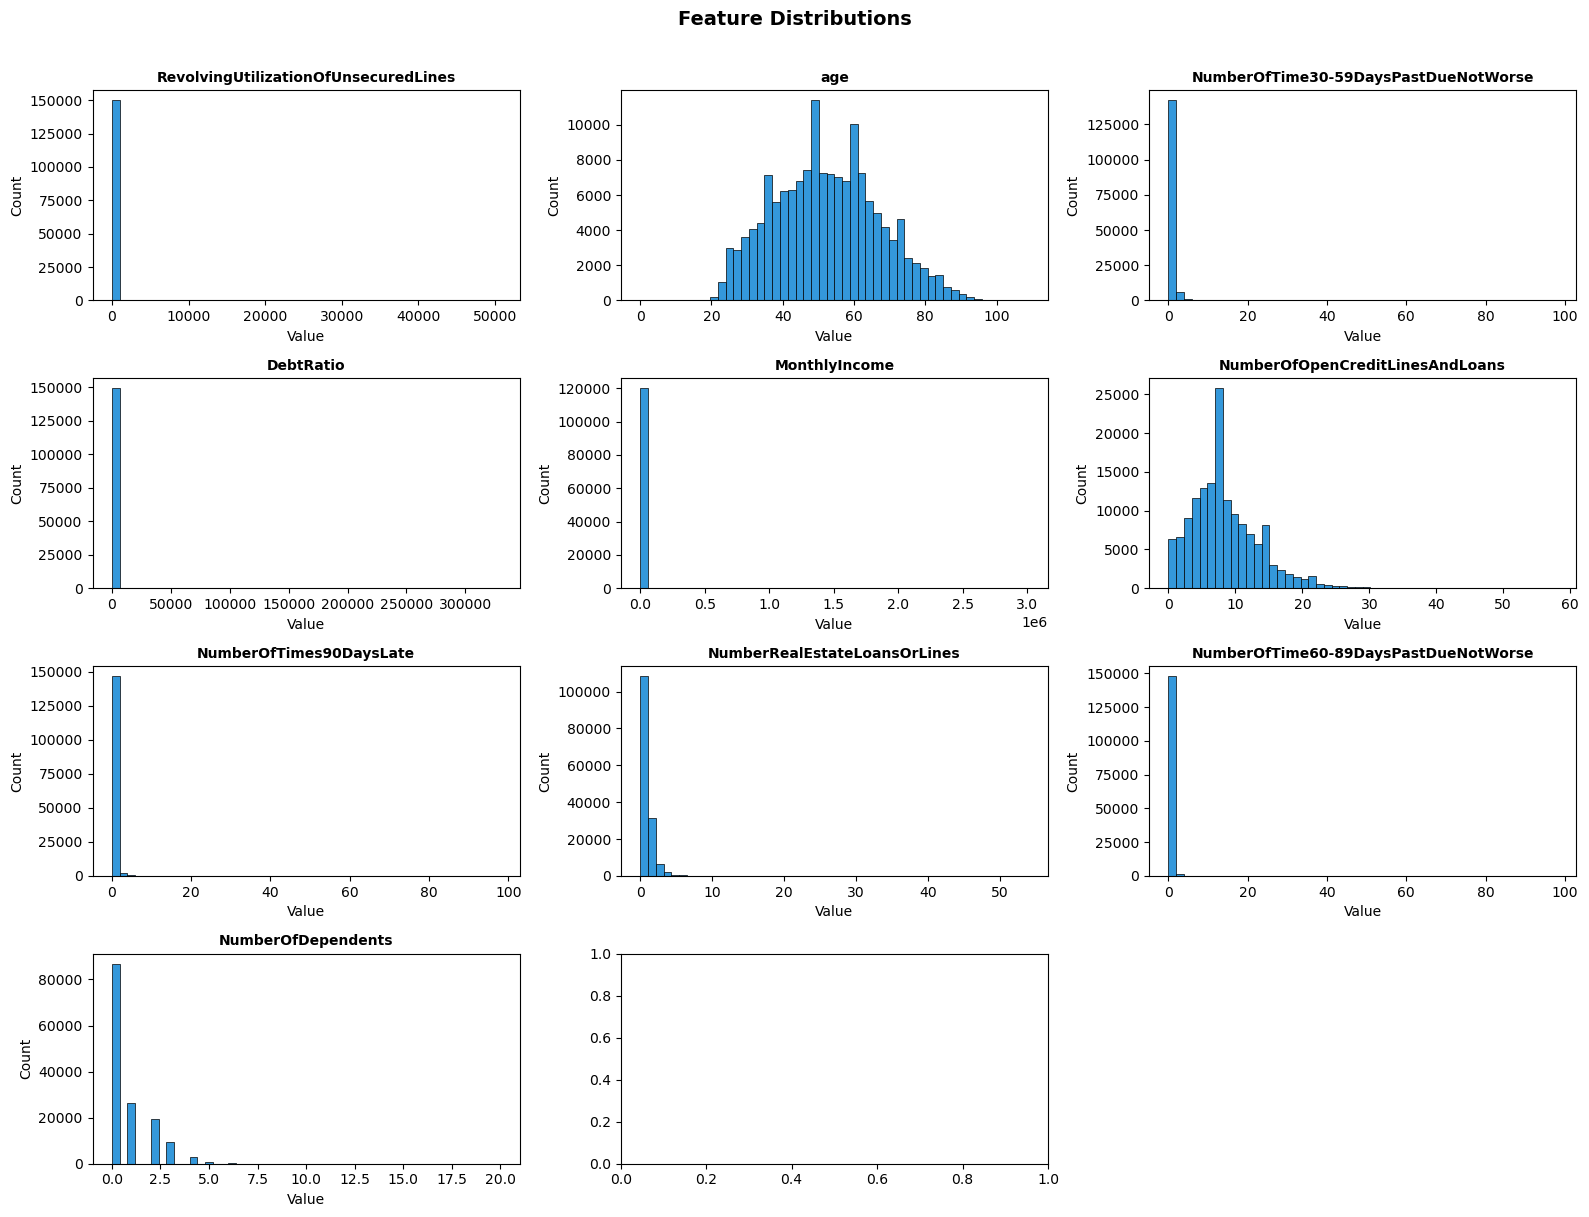

In [24]:
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=50, color='#3498db', 
                 edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide the empty 11th subplot
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=150)
plt.show()

#### Outlier Investigation

In [25]:
outlier_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

print("Outlier Investigation — 95th and 99th Percentiles:\n")
for col in outlier_cols:
    p95 = df[col].quantile(0.95)
    p99 = df[col].quantile(0.99)
    max_val = df[col].max()
    print(f"{col}")
    print(f"  95th percentile: {p95:.2f}  |  99th percentile: {p99:.2f}  |  Max: {max_val:.2f}")
    print()

Outlier Investigation — 95th and 99th Percentiles:

RevolvingUtilizationOfUnsecuredLines
  95th percentile: 1.00  |  99th percentile: 1.09  |  Max: 50708.00

DebtRatio
  95th percentile: 2449.00  |  99th percentile: 4979.04  |  Max: 329664.00

MonthlyIncome
  95th percentile: 14587.60  |  99th percentile: 25000.00  |  Max: 3008750.00

NumberOfTime30-59DaysPastDueNotWorse
  95th percentile: 2.00  |  99th percentile: 4.00  |  Max: 98.00

NumberOfTimes90DaysLate
  95th percentile: 1.00  |  99th percentile: 3.00  |  Max: 98.00

NumberOfTime60-89DaysPastDueNotWorse
  95th percentile: 1.00  |  99th percentile: 2.00  |  Max: 98.00



#### Age Check

In [26]:
print("Age distribution — suspicious values:")
print(df['age'].describe())
print(f"\nBorrowers under 18: {(df['age'] < 18).sum()}")
print(f"Borrowers over 100: {(df['age'] > 100).sum()}")

Age distribution — suspicious values:
count   150000.000
mean        52.295
std         14.772
min          0.000
25%         41.000
50%         52.000
75%         63.000
max        109.000
Name: age, dtype: float64

Borrowers under 18: 1
Borrowers over 100: 13


In [ ]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

print("Average Default Rate by Number of Late Payments:\n")
for col in late_cols:
    rate = df.groupby(col)['SeriousDlqin2yrs'].mean() * 100
    rate.index.name = 'Late Payments'
    rate.name = 'Default Rate (%)'
    print(f"--- {col} ---")
    print(rate.head(6).to_string())
    print()

Average Default Rate by Number of Late Payments:

NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
0    4.000
1   15.025
2   26.512
3   35.234
4   42.570
5   45.029

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
0    5.096
1   31.007
2   50.179
3   56.604
4   61.905
5   61.765

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
0    4.627
1   33.664
2   49.904
3   57.721
4   67.010
5   63.359

